# Acquisition models — QA-covariate variants

This notebook re-fits **only the acquisition models** from `paper_models.ipynb`
(SP volume, WM surface area, WB SP thickness — the `*_acq` specifications) under
two alternative QA covariate choices, and ends each section with a cross-model
R² comparison bar plot.

- **Section A — drop `qa_mean`**: `outcome ~ GA + stack_count`
- **Section B — swap `qa_mean` → `qa_diff`**: `outcome ~ GA + qa_diff + stack_count`
  (`qa_diff` = absolute within-pair QA difference, the paper's original "quality
  difference" covariate)

Everything else matches `paper_models.ipynb`: GA ≤ 32 weeks, two split pairs
(S1-S2, S3-S4) fit independently, N = 20 per pair for volume/surface and N = 13
per pair for thickness. Read the results as *consistency across pairs*.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from slides_helpers import diagnostics_grid, fit_and_present, model_comparison_table

DATA = Path('../data')
ASSETS = Path('../assets')
ASSETS.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

## Load data and build per-pair analysis frames

Same construction as `paper_models.ipynb`. Volume/surface frames already carry
both `qa_mean` and `qa_diff`; the thickness frames (`thickness_audit.csv`) only
ship `qa_mean`, so we merge the per-pair `qa_diff` from `raw_subject_data.csv`.

In [2]:
raw = pd.read_csv(DATA / 'raw_subject_data.csv')
splits_df = pd.read_csv(DATA / 'split_comparision_data.csv')
iqm = pd.read_csv(DATA / 'image_quality_metrics.csv')

# Restrict to GA <= 32 weeks (drops 3 late-GA subjects: FCB070, FCB184, FCB187)
GA_MAX = 32
_keep = raw.loc[raw['GA'] <= GA_MAX, ['subject_id', 'session_id']]
raw = raw.merge(_keep, on=['subject_id', 'session_id'], how='inner')
splits_df = splits_df.merge(_keep, on=['subject_id', 'session_id'], how='inner')
iqm = iqm.merge(_keep, on=['subject_id', 'session_id'], how='inner')

print('raw:', raw.shape, '| splits:', splits_df.shape, '| iqm:', iqm.shape)

# QA differences within each pair (paper's 'quality difference')
raw['qa_diff_S1S2'] = (raw['QA_S1'] - raw['QA_S2']).abs()
raw['qa_diff_S3S4'] = (raw['QA_S3'] - raw['QA_S4']).abs()


def build_pair(label):
    pair_tag = label.replace('-', '')  # 'S1S2'
    df = (
        splits_df[splits_df['split_pair'] == label]
        .merge(raw[['subject_id', 'session_id', 'stack_count',
                    f'qa_diff_{pair_tag}',
                    f'QA{pair_tag[1] + pair_tag[3]}_mean']],
               on=['subject_id', 'session_id'], how='left')
        .rename(columns={f'qa_diff_{pair_tag}': 'qa_diff',
                         f'QA{pair_tag[1] + pair_tag[3]}_mean': 'qa_mean'})
    )
    df['apd_sp'] = df['rel_diff_sp']
    df['apd_surface'] = (df['wm_surface_area_diff']
                          / df['wm_surface_area_mean'] * 100)
    return df

s12 = build_pair('S1-S2')
s34 = build_pair('S3-S4')
print('S1-S2 frame:', s12.shape, '| S3-S4 frame:', s34.shape)

raw: (20, 11) | splits: (40, 16) | iqm: (80, 25)
S1-S2 frame: (20, 21) | S3-S4 frame: (20, 21)


In [3]:
# --- Thickness frames (add per-pair qa_diff, which thickness_audit lacks) ----
thk_audit = pd.read_csv(DATA / 'thickness_audit.csv')
thk_audit = thk_audit.merge(_keep, on=['subject_id', 'session_id'], how='inner')

qa_diff_long = pd.concat([
    raw[['subject_id', 'session_id']].assign(
        split_pair='S1-S2', qa_diff=raw['qa_diff_S1S2']),
    raw[['subject_id', 'session_id']].assign(
        split_pair='S3-S4', qa_diff=raw['qa_diff_S3S4']),
])


def build_thk_pair(label):
    return (
        thk_audit[thk_audit['split_pair'] == label]
        .drop_duplicates(['subject_id', 'session_id'])
        .dropna(subset=['thk_diff'])
        .merge(qa_diff_long[qa_diff_long['split_pair'] == label]
               [['subject_id', 'session_id', 'qa_diff']],
               on=['subject_id', 'session_id'], how='left')
        .reset_index(drop=True)
    )


thk_s12 = build_thk_pair('S1-S2')
thk_s34 = build_thk_pair('S3-S4')
print('Thickness frames — S1-S2:', thk_s12.shape, '| S3-S4:', thk_s34.shape)
display(thk_s12[['subject_id', 'GA', 'thk_diff', 'qa_mean', 'qa_diff', 'stack_count']].head(3))

Thickness frames — S1-S2: (13, 27) | S3-S4: (13, 27)


,subject_id,GA,thk_diff,qa_mean,qa_diff,stack_count
0,FCB145,27.710,0.113,0.830,0.170,3
1,FCB191,25.710,0.057,0.530,0.250,5
2,FCB139,28.860,0.094,0.850,0.300,5


## Section A — acquisition models without `qa_mean`

Each acquisition model re-fit as `outcome ~ GA + stack_count` (the `qa_mean`
covariate dropped), independently for S1-S2 and S3-S4.


=== M_acq-qa (vol) | S1-S2 | R²=0.200 | F=2.13 | p=0.1500 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-2302.182,1401.015,-1.640,0.119,-5258.070,653.700,
GA,93.652,47.744,1.960,0.066,-7.080,194.380,
stack_count,34.899,37.692,0.930,0.367,-44.620,114.420,



=== M_acq-qa (vol) | S3-S4 | R²=0.262 | F=3.02 | p=0.0756 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-3032.194,1437.459,-2.110,0.050,-6064.970,0.580,
GA,119.044,48.985,2.430,0.026,15.690,222.390,*
stack_count,28.040,38.672,0.730,0.478,-53.550,109.630,


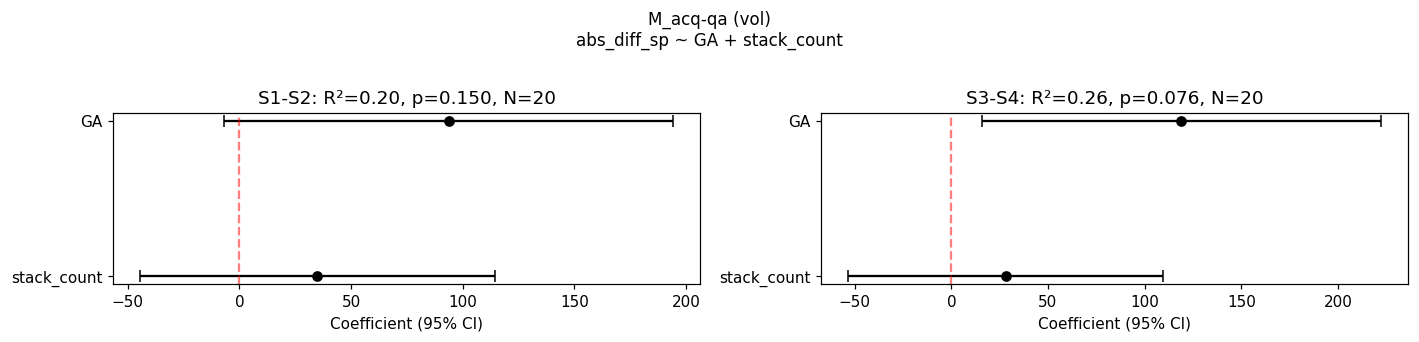


[M_acq-qa — SP volume (no qa_mean)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB195/MR-EI_Fetal_Neuro-26792482-20230322  studentized_resid=+2.72  resid=+1.18e+03  fitted=612  actual=1.79e+03
  2. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.89  resid=-827  fitted=858  actual=31
  3. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+1.88  resid=+847  fitted=768  actual=1.61e+03

[M_acq-qa — SP volume (no qa_mean)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB139/2019.01.31-032Y-MR_EI_Fetal_Neuro-29172  studentized_resid=+2.45  resid=+1.15e+03  fitted=544  actual=1.69e+03
  2. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.85  resid=-834  fitted=871  actual=36.7
  3. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+1.62  resid=+757  fitted=701  actual=1.46e+03


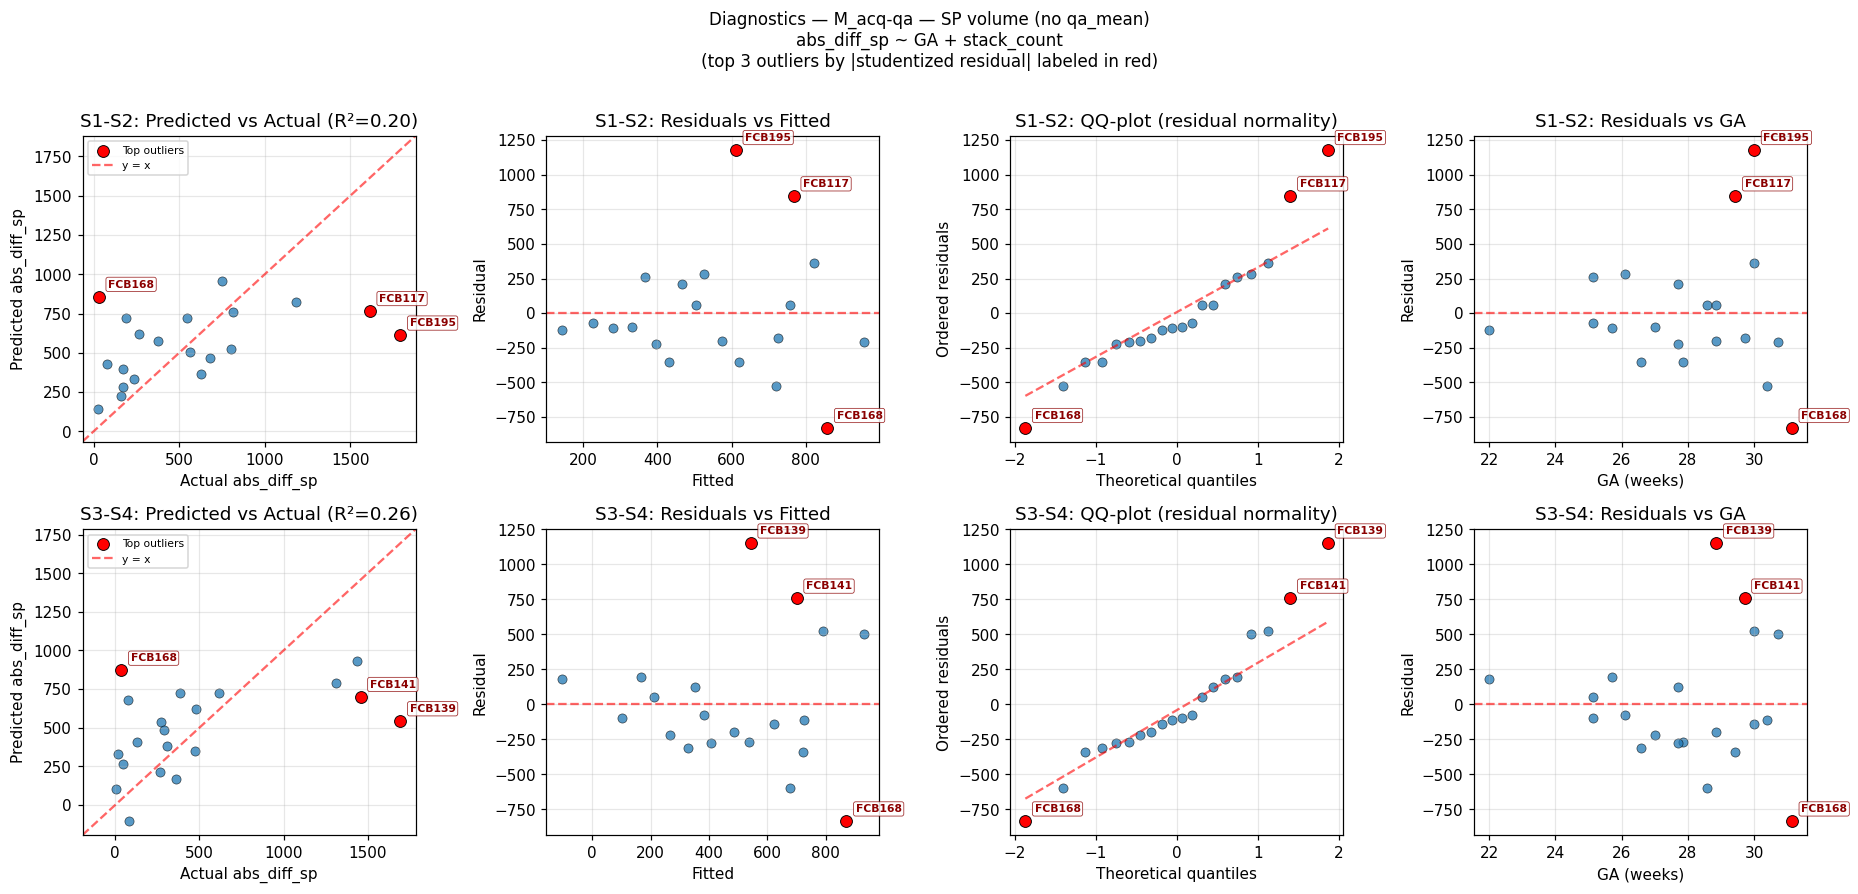

In [4]:
noqa_results = {}
NOQA_PREDICTORS = ['GA', 'stack_count']

noqa_results['M_acq-qa (vol)'] = fit_and_present(
    'abs_diff_sp', NOQA_PREDICTORS, s12, s34,
    'M_acq-qa (vol)', 'noqa_vol_M_acq', ASSETS, save_tables=False,
)
diagnostics_grid(
    noqa_results['M_acq-qa (vol)'], s12, s34,
    'abs_diff_sp', NOQA_PREDICTORS,
    'M_acq-qa — SP volume (no qa_mean)',
)
plt.show()


=== S_acq-qa (surf) | S1-S2 | R²=0.098 | F=0.92 | p=0.4166 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-292.243,1188.275,-0.250,0.809,-2799.280,2214.800,
GA,26.908,40.494,0.660,0.515,-58.530,112.340,
stack_count,-34.194,31.968,-1.070,0.300,-101.640,33.250,



=== S_acq-qa (surf) | S3-S4 | R²=0.141 | F=1.39 | p=0.2756 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-79.589,394.328,-0.200,0.842,-911.550,752.370,
GA,10.818,13.438,0.810,0.432,-17.530,39.170,
stack_count,-14.022,10.609,-1.320,0.204,-36.400,8.360,


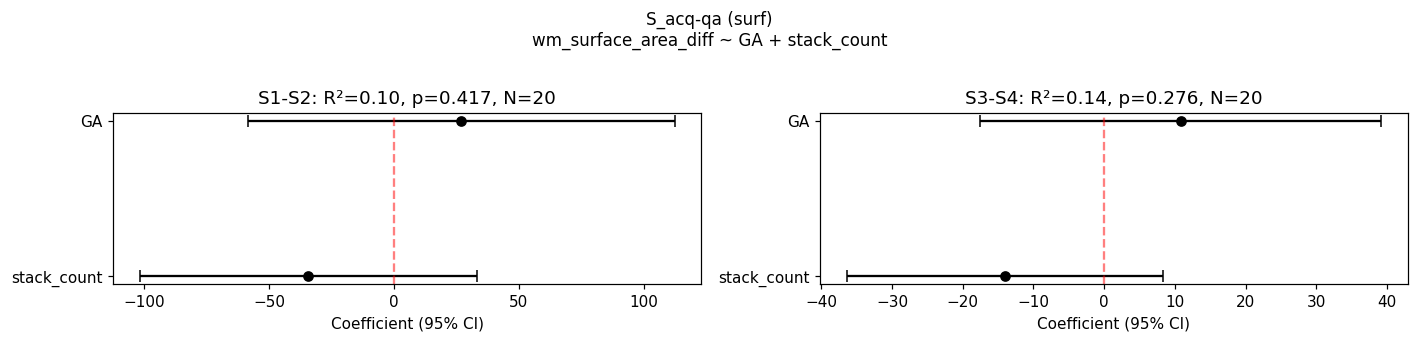


[S_acq-qa — WM surface area (no qa_mean)] S1-S2 — top 3 outliers (|studentized residual|):
  1. 4712320/MR-EI_Fetal_Body-26831832-20230502  studentized_resid=+3.35  resid=+1.27e+03  fitted=355  actual=1.62e+03
  2. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+1.90  resid=+704  fitted=332  actual=1.04e+03
  3. FCB145/2019.03.20-032Y-MR_EI_Fetal_Neuro-29197  studentized_resid=-0.92  resid=-343  fitted=351  actual=8.18

[S_acq-qa — WM surface area (no qa_mean)] S3-S4 — top 3 outliers (|studentized residual|):
  1. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+3.57  resid=+439  fitted=170  actual=609
  2. FCB149/2019.04.11-030Y-MR_EI_Fetal_Neuro-29205  studentized_resid=-1.13  resid=-140  fitted=191  actual=50.7
  3. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+1.04  resid=+131  fitted=113  actual=244


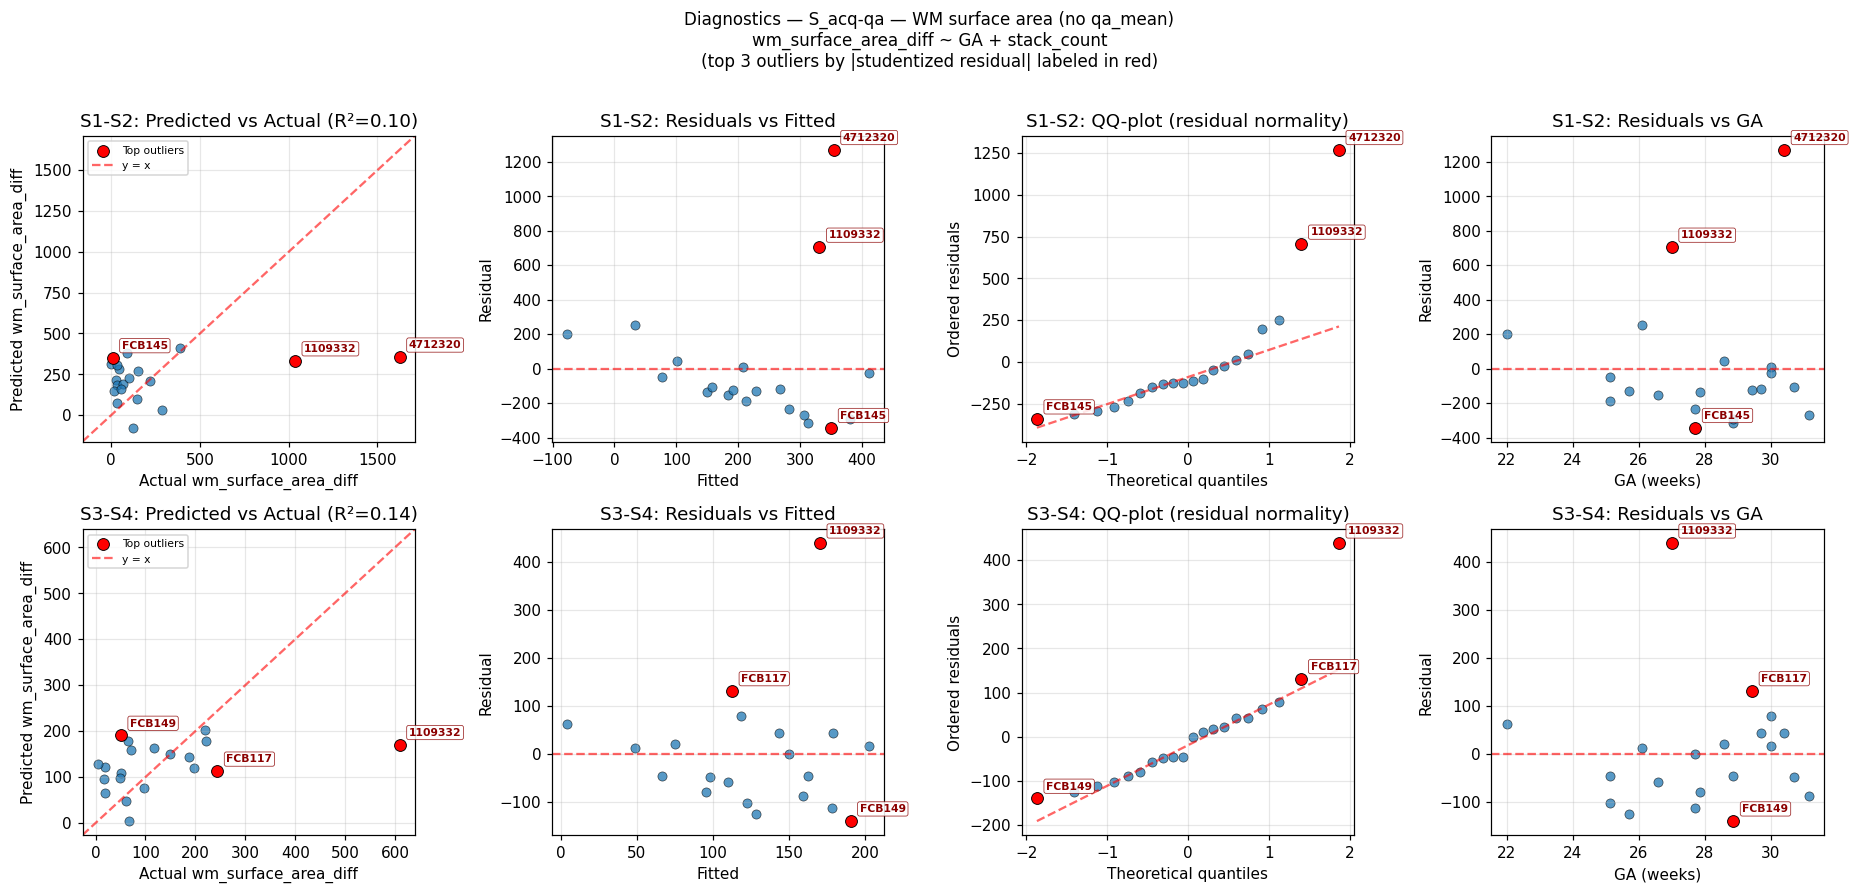

In [5]:
noqa_results['S_acq-qa (surf)'] = fit_and_present(
    'wm_surface_area_diff', NOQA_PREDICTORS, s12, s34,
    'S_acq-qa (surf)', 'noqa_surf_S_acq', ASSETS, save_tables=False,
)
diagnostics_grid(
    noqa_results['S_acq-qa (surf)'], s12, s34,
    'wm_surface_area_diff', NOQA_PREDICTORS,
    'S_acq-qa — WM surface area (no qa_mean)',
)
plt.show()


=== T_acq-qa (thk) | S1-S2 | R²=0.314 | F=2.29 | p=0.1519 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.732,0.420,-1.740,0.112,-1.670,0.200,
GA,0.032,0.015,2.130,0.059,-0.000,0.060,
stack_count,-0.002,0.013,-0.140,0.888,-0.030,0.030,



=== T_acq-qa (thk) | S3-S4 | R²=0.312 | F=2.27 | p=0.1537 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-1.111,0.714,-1.560,0.151,-2.700,0.480,
GA,0.052,0.026,2.010,0.072,-0.010,0.110,
stack_count,-0.016,0.022,-0.730,0.484,-0.060,0.030,


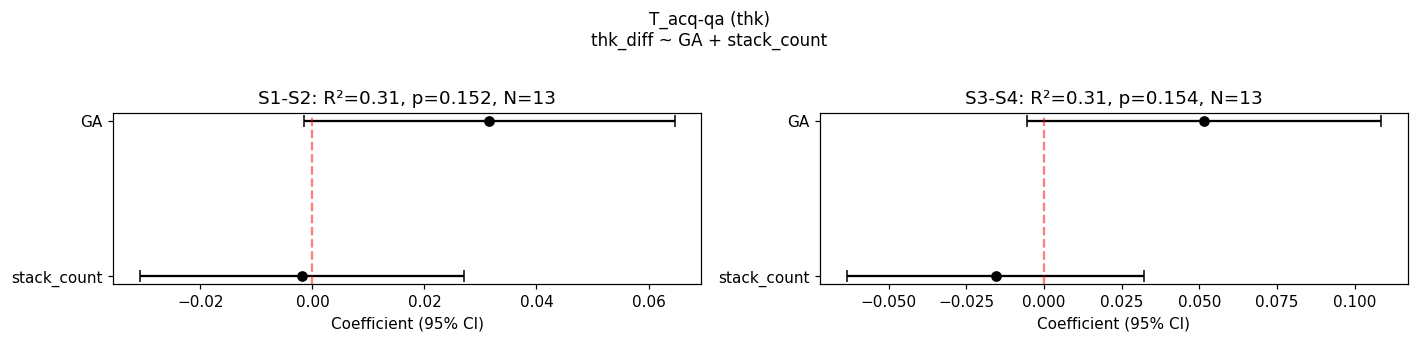


[T_acq-qa — WB SP thickness (no qa_mean)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.65  resid=+0.302  fitted=0.193  actual=0.495
  2. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.27  resid=-0.141  fitted=0.15  actual=0.00872
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.15  resid=+0.0959  fitted=-0.0579  actual=0.038

[T_acq-qa — WB SP thickness (no qa_mean)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.56  resid=+0.477  fitted=0.311  actual=0.788
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.54  resid=+0.206  fitted=-0.149  actual=0.0572
  3. FCB147/2019.05.08-036Y-MR_EI_Fetal_Neuro-29187  studentized_resid=-1.16  resid=-0.191  fitted=0.3  actual=0.109


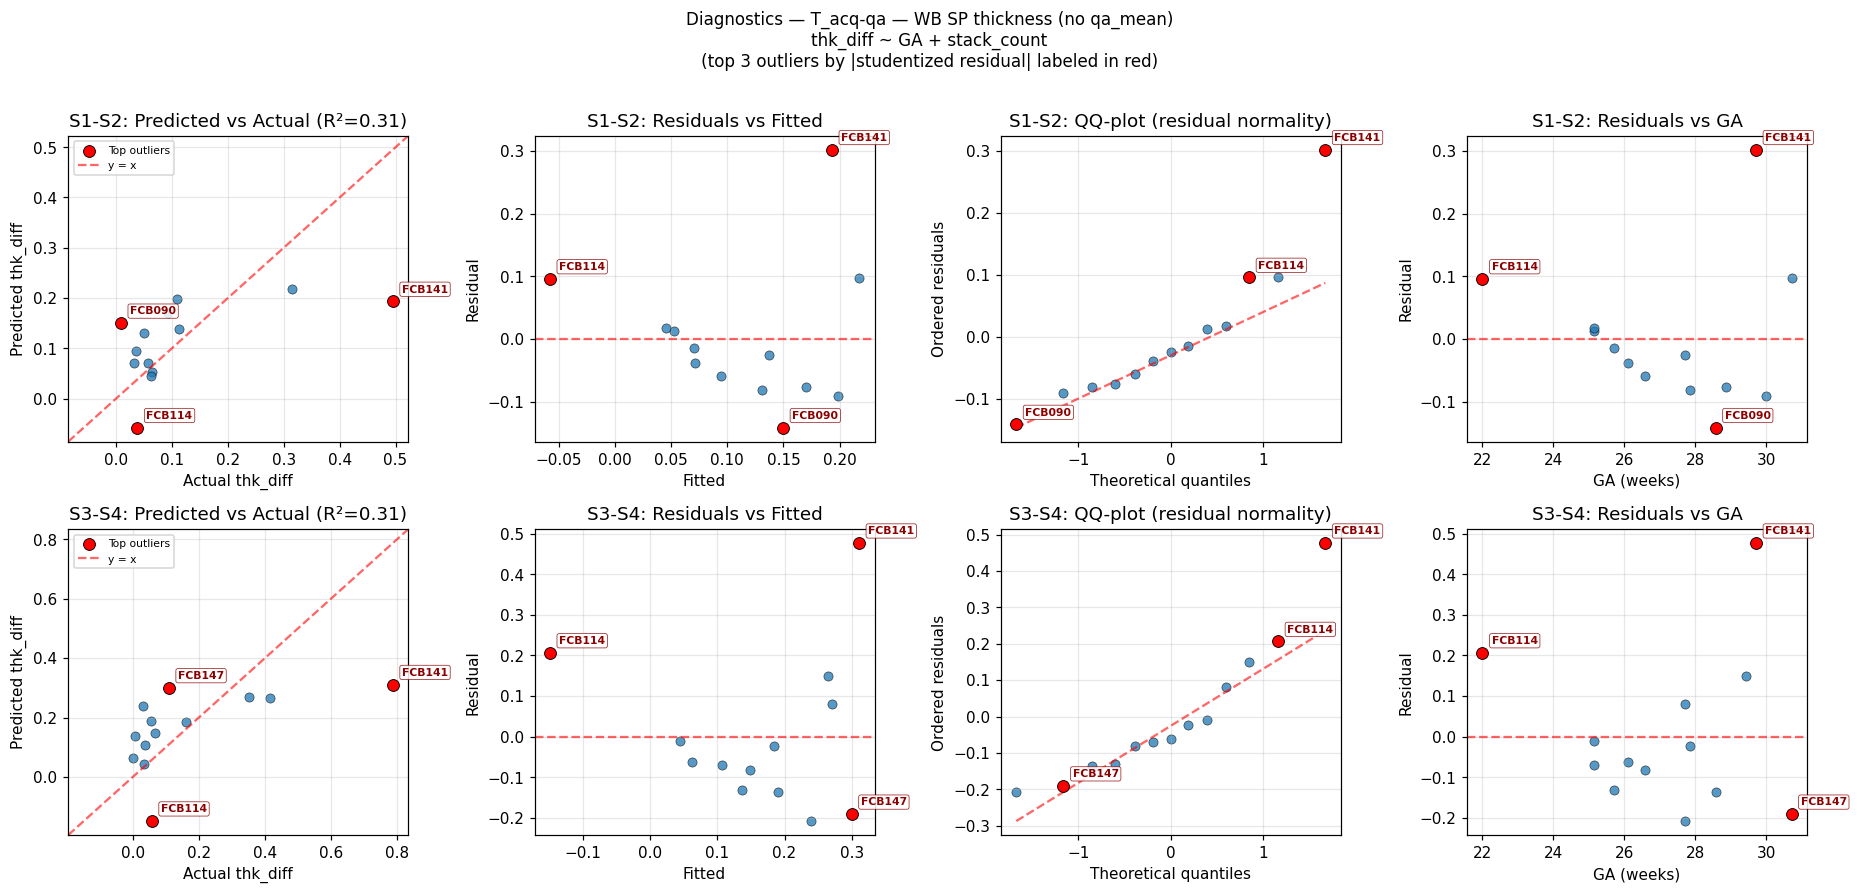

In [6]:
noqa_results['T_acq-qa (thk)'] = fit_and_present(
    'thk_diff', NOQA_PREDICTORS, thk_s12, thk_s34,
    'T_acq-qa (thk)', 'noqa_thk_T_acq', ASSETS, save_tables=False,
)
diagnostics_grid(
    noqa_results['T_acq-qa (thk)'], thk_s12, thk_s34,
    'thk_diff', NOQA_PREDICTORS,
    'T_acq-qa — WB SP thickness (no qa_mean)',
)
plt.show()

### Section A — cross-model R² comparison

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,M_acq-qa (vol),S1-S2,20,0.200,0.106,0.150,93.652,0.066
1,M_acq-qa (vol),S3-S4,20,0.262,0.175,0.076,119.044,0.026
2,S_acq-qa (surf),S1-S2,20,0.098,-0.008,0.417,26.908,0.515
3,S_acq-qa (surf),S3-S4,20,0.141,0.040,0.276,10.818,0.432
4,T_acq-qa (thk),S1-S2,13,0.314,0.177,0.152,0.032,0.059
5,T_acq-qa (thk),S3-S4,13,0.312,0.175,0.154,0.052,0.072


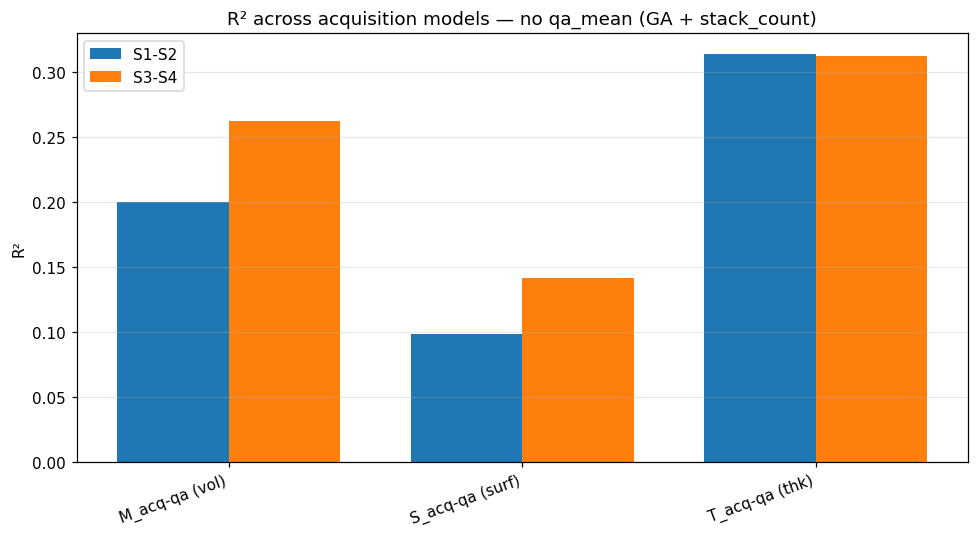

Saved → assets/model_comparison_noqa_table.csv, assets/model_comparison_noqa_R2.png


In [7]:
comparison_noqa = model_comparison_table(noqa_results)
comparison_noqa.to_csv(ASSETS / 'model_comparison_noqa_table.csv', index=False)
display(comparison_noqa)

fig, ax = plt.subplots(figsize=(9, 5))
models = comparison_noqa['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison_noqa[comparison_noqa['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R²')
ax.set_title('R² across acquisition models — no qa_mean (GA + stack_count)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'model_comparison_noqa_R2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → assets/model_comparison_noqa_table.csv, assets/model_comparison_noqa_R2.png')

## Section B — acquisition models with `qa_diff` instead of `qa_mean`

Each acquisition model re-fit as `outcome ~ GA + qa_diff + stack_count`, where
`qa_diff` is the absolute within-pair QA difference (the paper's original
"quality difference" covariate), independently for S1-S2 and S3-S4.


=== M_acq_qd (vol) | S1-S2 | R²=0.217 | F=1.47 | p=0.2593 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-2324.829,1429.710,-1.630,0.123,-5355.680,706.020,
GA,98.368,49.377,1.990,0.064,-6.310,203.040,
qa_diff,-822.300,1417.301,-0.580,0.570,-3826.840,2182.240,
stack_count,30.174,39.302,0.770,0.454,-53.140,113.490,



=== M_acq_qd (vol) | S3-S4 | R²=0.334 | F=2.68 | p=0.0819 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-3307.968,1422.543,-2.330,0.034,-6323.620,-292.310,*
GA,119.523,47.953,2.490,0.024,17.870,221.180,*
qa_diff,2809.727,2129.266,1.320,0.206,-1704.120,7323.570,
stack_count,41.838,39.273,1.070,0.303,-41.420,125.090,


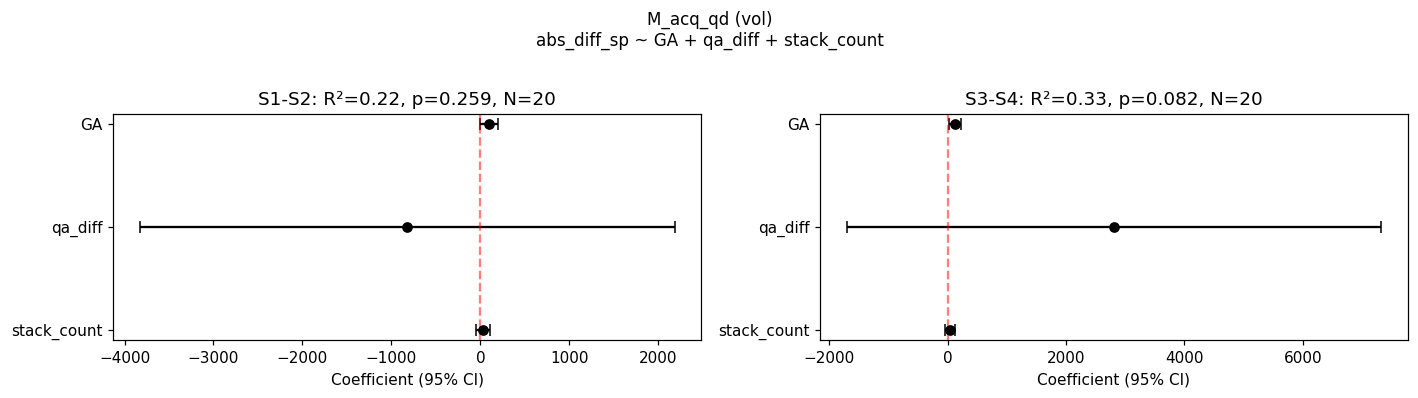


[M_acq_qd — SP volume (qa_diff)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB195/MR-EI_Fetal_Neuro-26792482-20230322  studentized_resid=+2.66  resid=+1.08e+03  fitted=717  actual=1.79e+03
  2. FCB117/2018.03.01-032Y-MR_EI_Fetal_Neuro-18053  studentized_resid=+1.88  resid=+863  fitted=751  actual=1.61e+03
  3. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.85  resid=-828  fitted=859  actual=31

[M_acq_qd — SP volume (qa_diff)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB139/2019.01.31-032Y-MR_EI_Fetal_Neuro-29172  studentized_resid=+2.14  resid=+782  fitted=913  actual=1.69e+03
  2. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.09  resid=+922  fitted=536  actual=1.46e+03
  3. FCB168/2020.03.12-021Y-MR_EI_Fetal_Neuro-30926  studentized_resid=-1.97  resid=-867  fitted=904  actual=36.7


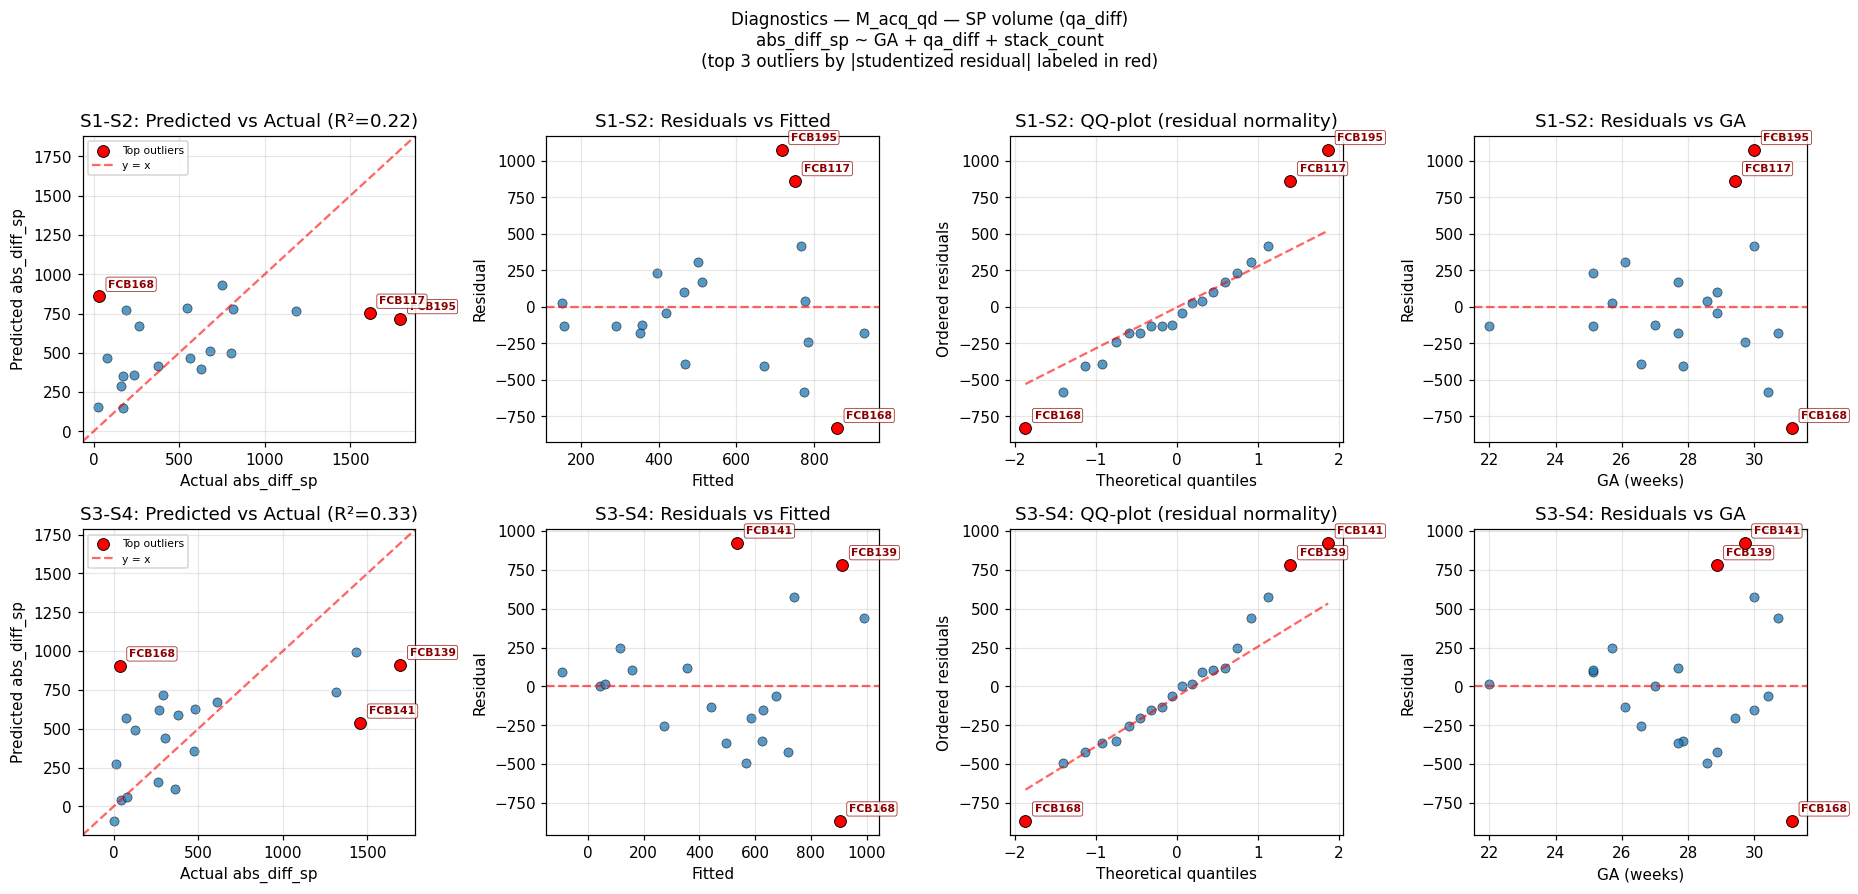

In [8]:
qadiff_results = {}
QADIFF_PREDICTORS = ['GA', 'qa_diff', 'stack_count']

qadiff_results['M_acq_qd (vol)'] = fit_and_present(
    'abs_diff_sp', QADIFF_PREDICTORS, s12, s34,
    'M_acq_qd (vol)', 'qadiff_vol_M_acq', ASSETS, save_tables=False,
)
diagnostics_grid(
    qadiff_results['M_acq_qd (vol)'], s12, s34,
    'abs_diff_sp', QADIFF_PREDICTORS,
    'M_acq_qd — SP volume (qa_diff)',
)
plt.show()


=== S_acq_qd (surf) | S1-S2 | R²=0.175 | F=1.13 | p=0.3666 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-331.319,1171.892,-0.280,0.781,-2815.620,2152.980,
GA,35.045,40.473,0.870,0.399,-50.750,120.840,
qa_diff,-1418.861,1161.720,-1.220,0.240,-3881.600,1043.880,
stack_count,-42.347,32.215,-1.310,0.207,-110.640,25.950,



=== S_acq_qd (surf) | S3-S4 | R²=0.297 | F=2.25 | p=0.1217 | N=20 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,23.357,371.710,0.060,0.951,-764.630,811.350,
GA,10.639,12.530,0.850,0.408,-15.920,37.200,
qa_diff,-1048.864,556.376,-1.890,0.078,-2228.330,130.600,
stack_count,-19.172,10.262,-1.870,0.080,-40.930,2.580,


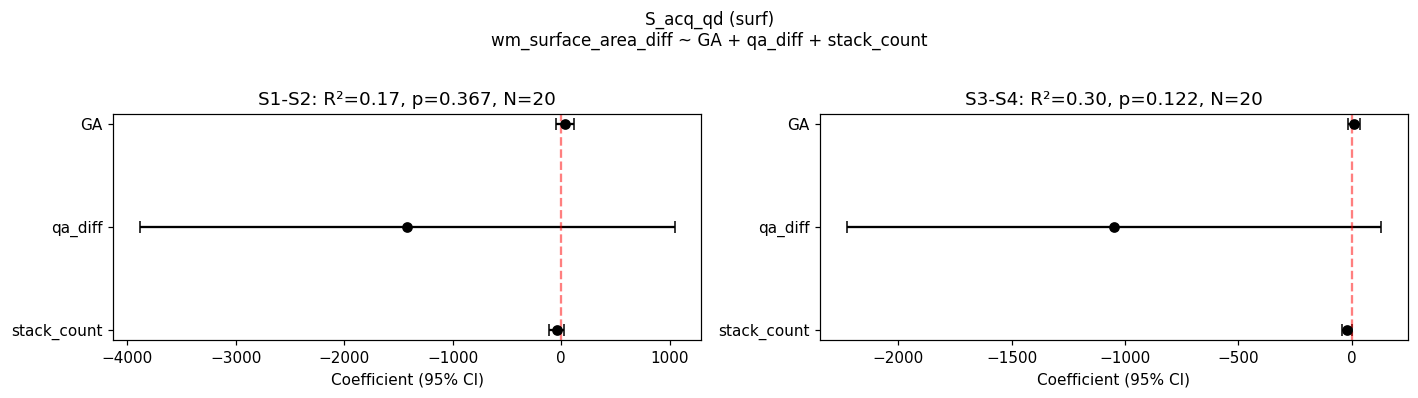


[S_acq_qd — WM surface area (qa_diff)] S1-S2 — top 3 outliers (|studentized residual|):
  1. 4712320/MR-EI_Fetal_Body-26831832-20230502  studentized_resid=+3.22  resid=+1.17e+03  fitted=451  actual=1.62e+03
  2. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+1.82  resid=+661  fitted=374  actual=1.04e+03
  3. FCB077/2016.02.02-025Y-MR_EI_Fetal_Neuro-7880  studentized_resid=-0.85  resid=-299  fitted=324  actual=24.7

[S_acq_qd — WM surface area (qa_diff)] S3-S4 — top 3 outliers (|studentized residual|):
  1. 1109332/MR-EI_Fetal_Body-26810110-20230404  studentized_resid=+3.36  resid=+356  fitted=253  actual=609
  2. FCB077/2016.02.02-025Y-MR_EI_Fetal_Neuro-7880  studentized_resid=-1.63  resid=-175  fitted=195  actual=19.8
  3. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.44  resid=+125  fitted=-58.4  actual=66.2


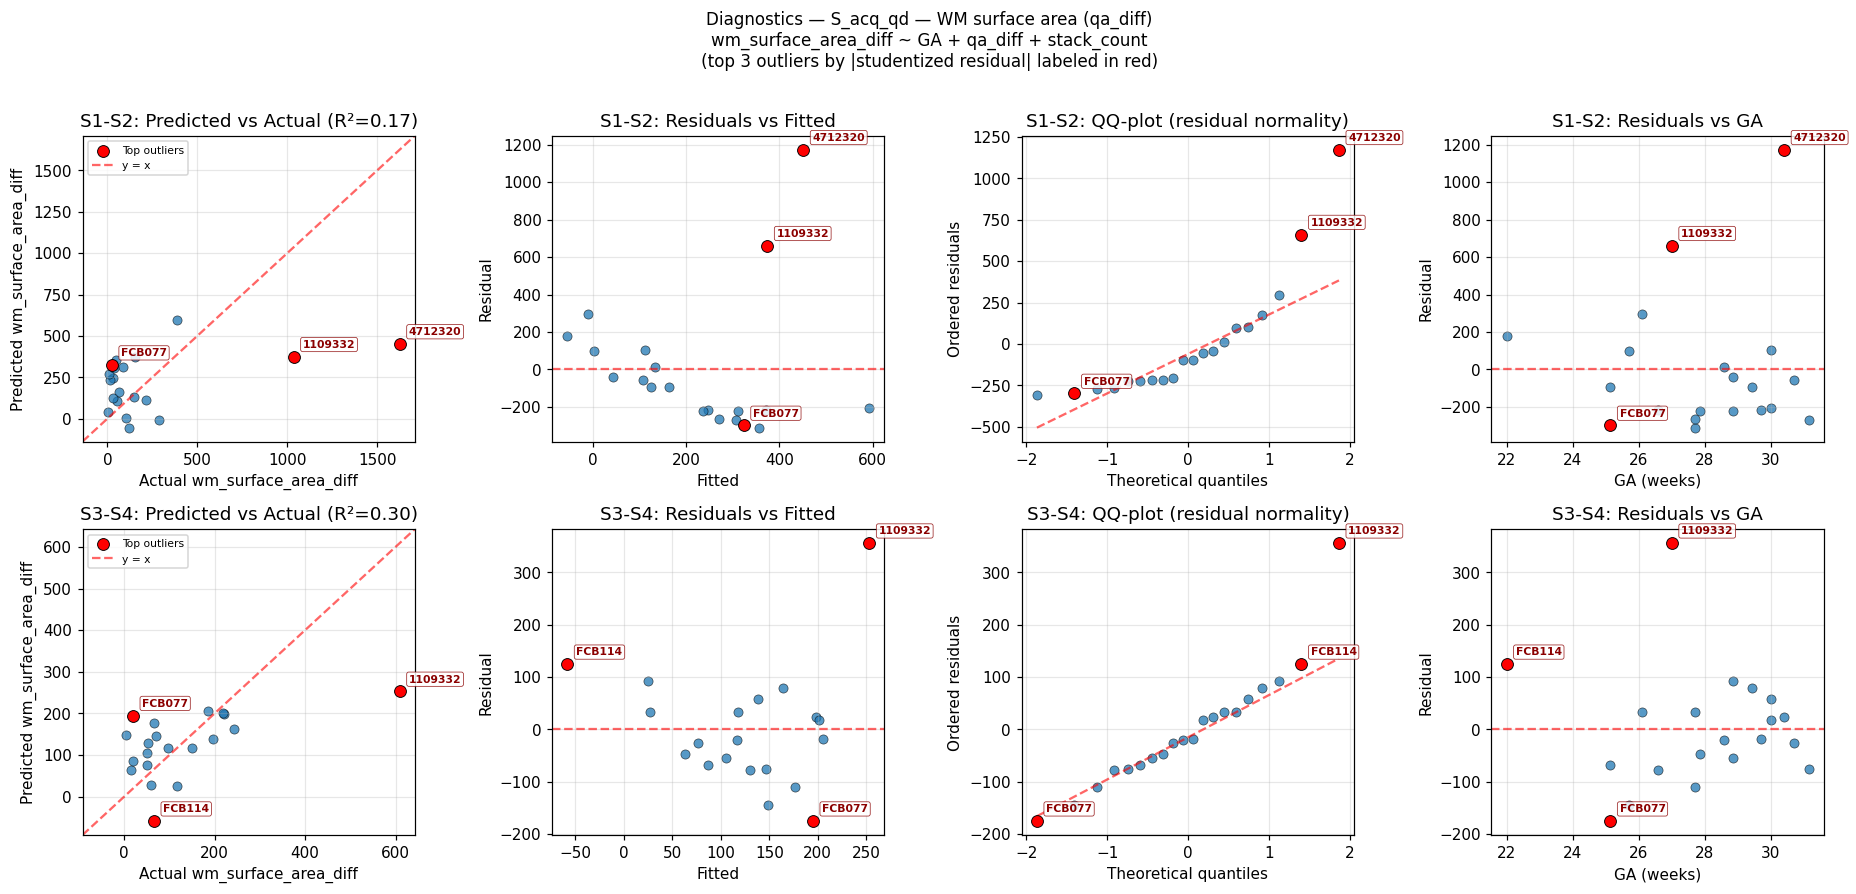

In [9]:
qadiff_results['S_acq_qd (surf)'] = fit_and_present(
    'wm_surface_area_diff', QADIFF_PREDICTORS, s12, s34,
    'S_acq_qd (surf)', 'qadiff_surf_S_acq', ASSETS, save_tables=False,
)
diagnostics_grid(
    qadiff_results['S_acq_qd (surf)'], s12, s34,
    'wm_surface_area_diff', QADIFF_PREDICTORS,
    'S_acq_qd — WM surface area (qa_diff)',
)
plt.show()


=== T_acq_qd (thk) | S1-S2 | R²=0.391 | F=1.92 | p=0.1964 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.784,0.420,-1.870,0.095,-1.730,0.170,
GA,0.037,0.016,2.380,0.041,0.000,0.070,*
qa_diff,-0.481,0.453,-1.060,0.315,-1.500,0.540,
stack_count,-0.009,0.015,-0.630,0.542,-0.040,0.020,



=== T_acq_qd (thk) | S3-S4 | R²=0.357 | F=1.67 | p=0.2423 | N=13 ===


,Coef,SE,t,p,CI_low,CI_high,sig
const,-0.856,0.796,-1.080,0.310,-2.660,0.940,
GA,0.045,0.027,1.630,0.138,-0.020,0.110,
qa_diff,-1.345,1.695,-0.790,0.448,-5.180,2.490,
stack_count,-0.017,0.022,-0.760,0.468,-0.070,0.030,


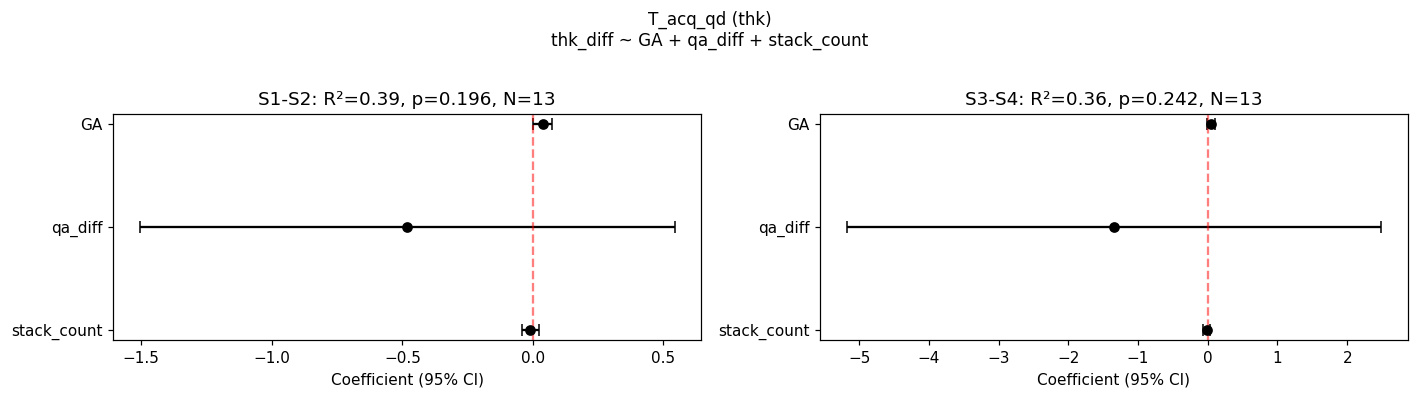


[T_acq_qd — WB SP thickness (qa_diff)] S1-S2 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.45  resid=+0.247  fitted=0.248  actual=0.495
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.36  resid=+0.111  fitted=-0.0729  actual=0.038
  3. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.36  resid=-0.15  fitted=0.158  actual=0.00872

[T_acq_qd — WB SP thickness (qa_diff)] S3-S4 — top 3 outliers (|studentized residual|):
  1. FCB141/2019.04.03-032Y-MR_EI_Fetal_Neuro-29199  studentized_resid=+2.38  resid=+0.432  fitted=0.356  actual=0.788
  2. FCB114/2017.06.26-027Y-MR_EI_Fetal_Neuro-17914  studentized_resid=+1.95  resid=+0.247  fitted=-0.19  actual=0.0572
  3. FCB090/2016.07.24-029Y-MR_EI_Fetal_Neuro-12836  studentized_resid=-1.04  resid=-0.185  fitted=0.239  actual=0.0539


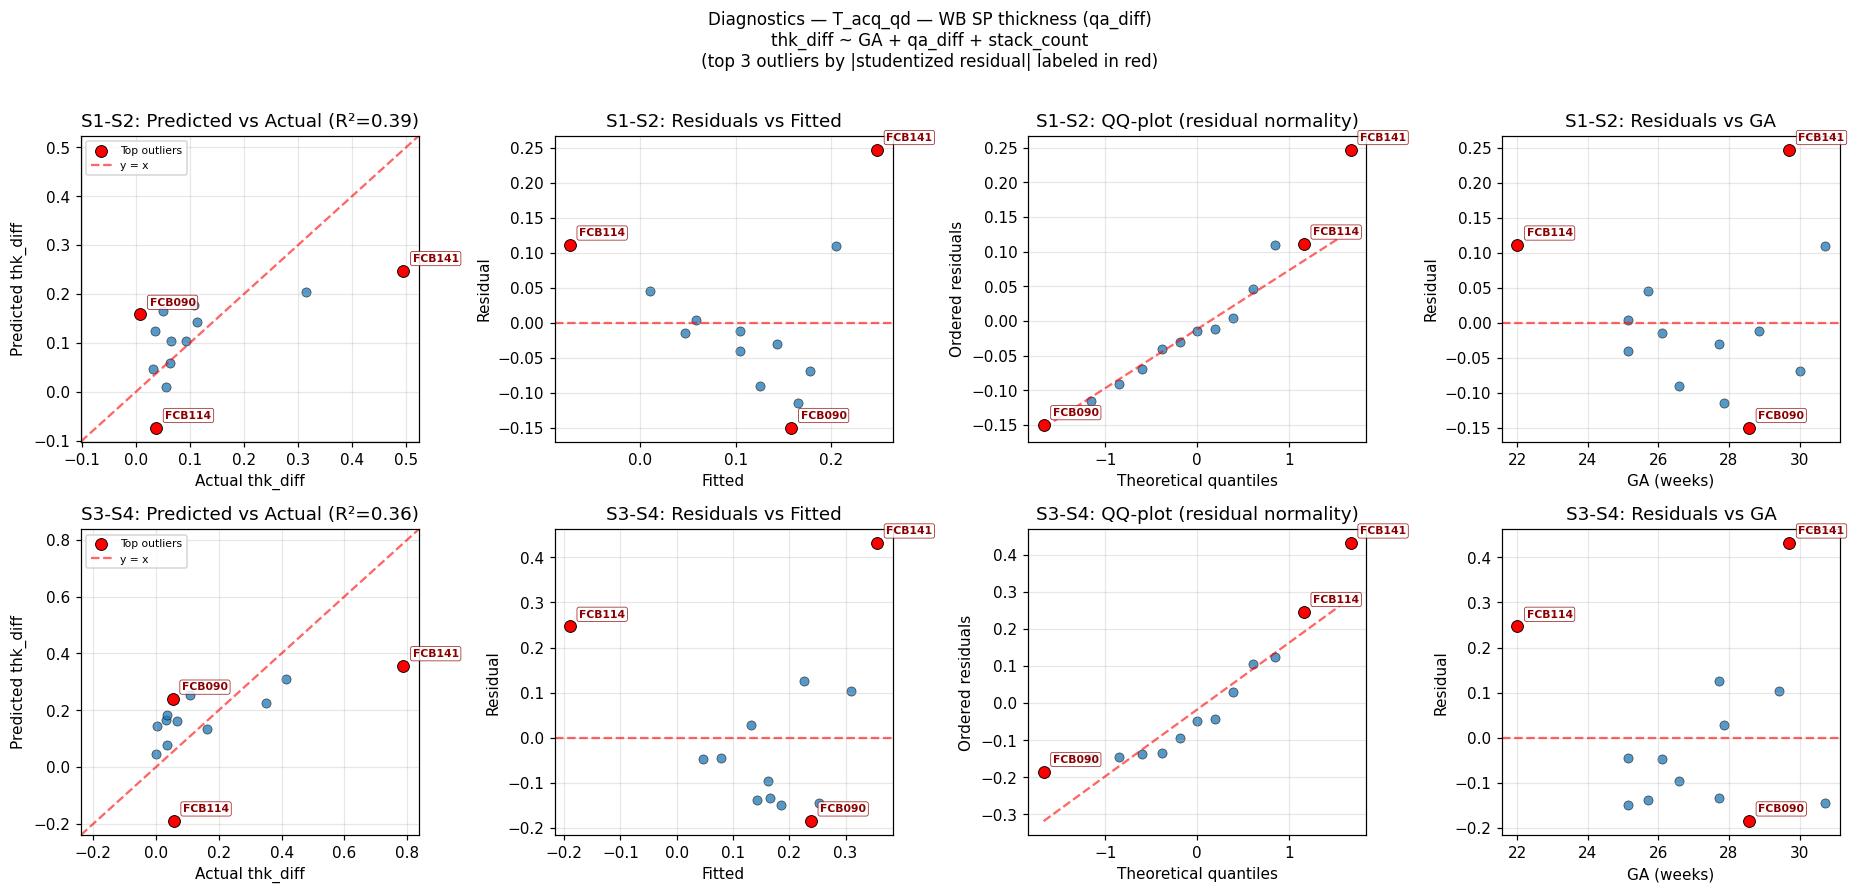

In [10]:
qadiff_results['T_acq_qd (thk)'] = fit_and_present(
    'thk_diff', QADIFF_PREDICTORS, thk_s12, thk_s34,
    'T_acq_qd (thk)', 'qadiff_thk_T_acq', ASSETS, save_tables=False,
)
diagnostics_grid(
    qadiff_results['T_acq_qd (thk)'], thk_s12, thk_s34,
    'thk_diff', QADIFF_PREDICTORS,
    'T_acq_qd — WB SP thickness (qa_diff)',
)
plt.show()

### Section B — cross-model R² comparison

,model,pair,N,R2,adj_R2,F_p,GA_coef,GA_p
0,M_acq_qd (vol),S1-S2,20,0.217,0.070,0.259,98.368,0.064
1,M_acq_qd (vol),S3-S4,20,0.334,0.210,0.082,119.523,0.024
2,S_acq_qd (surf),S1-S2,20,0.175,0.020,0.367,35.045,0.399
3,S_acq_qd (surf),S3-S4,20,0.297,0.165,0.122,10.639,0.408
4,T_acq_qd (thk),S1-S2,13,0.391,0.187,0.196,0.037,0.041
5,T_acq_qd (thk),S3-S4,13,0.357,0.143,0.242,0.045,0.138


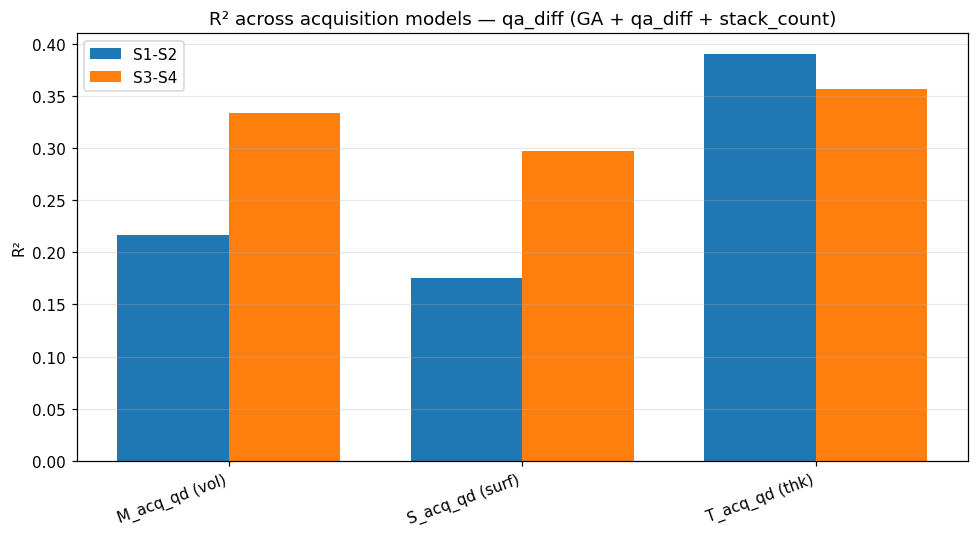

Saved → assets/model_comparison_qadiff_table.csv, assets/model_comparison_qadiff_R2.png


In [11]:
comparison_qadiff = model_comparison_table(qadiff_results)
comparison_qadiff.to_csv(ASSETS / 'model_comparison_qadiff_table.csv', index=False)
display(comparison_qadiff)

fig, ax = plt.subplots(figsize=(9, 5))
models = comparison_qadiff['model'].unique()
x = np.arange(len(models))
w = 0.38
for i, pair in enumerate(['S1-S2', 'S3-S4']):
    sub = comparison_qadiff[comparison_qadiff['pair'] == pair].set_index('model').reindex(models)
    ax.bar(x + (i - 0.5) * w, sub['R2'], width=w, label=pair)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('R²')
ax.set_title('R² across acquisition models — qa_diff (GA + qa_diff + stack_count)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(ASSETS / 'model_comparison_qadiff_R2.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → assets/model_comparison_qadiff_table.csv, assets/model_comparison_qadiff_R2.png')